# Importação de bibliotecas

In [1]:
# leitura dos arquivos e criação de dataframes
%pip install pandas
import pandas as pd

# leitura do arquivo xlsx
%pip install openpyxl

# elaboração dos gráficos
%pip install matplotlib
import matplotlib.pyplot as plt

# adição de rótulos de dados nos gráficos
%pip install seaborn
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Transformação dos dados

In [2]:
# lendo o arquivo csv com dados do caged
caged = pd.read_csv('dados_caged.csv', sep=';')
display(caged)

,cd_uf,cd_mun,dt_competencia,cd_admitidos_desligados,cd_cbo,nr_horas,nr_salario,nr_saldo,cd_tipo_movimentacao,cd_cnae_classe,fonte,nr_admitidos,nr_desligados,cd_cnae_sub,cd_familia
0,42,420200,202101,NaN,331105,4400.0,"3500,00",1,40,85121,CAGEDEXC202102,0,-1,8512100,3311
1,42,420840,202101,NaN,784205,4400.0,"1388,81",-1,10,10121,CAGEDEXC202102,-1,0,1012103,7842
2,42,420890,202101,NaN,911305,2000.0,"738,00",-1,10,24512,CAGEDEXC202102,-1,0,2451200,9113
3,42,420460,202101,NaN,517330,4400.0,"1452,66",-1,20,80111,CAGEDEXC202102,-1,0,8011101,5173
4,42,420750,202101,NaN,712205,4400.0,"2611,48",1,40,47440,CAGEDEXC202102,0,-1,4744005,7122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5613613,42,421190,202212,NaN,717020,4400.0,"1740,00",-1,43,42995,CAGEDMOV202212,0,1,4299599,7170
5613614,42,420240,202212,NaN,231210,4000.0,"5984,32",-1,45,84116,CAGEDMOV202212,0,1,8411600,2312
5613615,42,420850,202212,NaN,411005,4400.0,"1620,00",-1,43,46125,CAGEDMOV202212,0,1,4612500,4110
5613616,42,420910,202212,NaN,142305,4400.0,"2000,00",-1,31,47814,CAGEDMOV202212,0,1,4781400,1423


In [3]:
# filtrando e contando os dados pela coluna cbo das profissões steam
filtro1 = caged['cd_cbo'].astype(str).str.startswith('20')
filtro2 = caged['cd_cbo'].astype(str).str.startswith('21')
filtro3 = caged['cd_cbo'].astype(str).str.startswith('22')

print(filtro1.value_counts())
print(filtro2.value_counts())
print(filtro3.value_counts())

False    5612253
True        1365
Name: cd_cbo, dtype: int64
False    5579942
True       33676
Name: cd_cbo, dtype: int64
False    5560984
True       52634
Name: cd_cbo, dtype: int64


In [4]:
# juntando os filtros e exibindo os valores verdadeiros
caged_filtrado = (caged.loc[filtro1 | filtro2 | filtro3])
display(caged_filtrado)

,cd_uf,cd_mun,dt_competencia,cd_admitidos_desligados,cd_cbo,nr_horas,nr_salario,nr_saldo,cd_tipo_movimentacao,cd_cnae_classe,fonte,nr_admitidos,nr_desligados,cd_cnae_sub,cd_familia
108,42,420460,202101,NaN,224135,4400.0,"3000,00",1,43,85911,CAGEDEXC202104,0,-1,8591100,2241
137,42,420460,202101,NaN,224135,4400.0,"1045,00",1,43,85911,CAGEDEXC202104,0,-1,8591100,2241
263,42,420240,202101,NaN,223505,3600.0,"2210,00",-1,20,86101,CAGEDEXC202106,-1,0,8610101,2235
409,42,420540,202101,NaN,214205,1000.0,"2018,75",1,40,71197,CAGEDEXC202212,0,-1,7119799,2142
416,42,420210,202101,NaN,225125,4000.0,",00",1,25,84116,CAGEDFOR202102,1,0,8411600,2251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612899,42,420070,202212,NaN,212420,4400.0,"3300,00",-1,40,62015,CAGEDMOV202212,0,1,6201501,2124
5613001,42,420540,202212,NaN,212320,4000.0,"9633,90",-1,31,63119,CAGEDMOV202212,0,1,6311900,2123
5613370,42,421670,202212,NaN,212405,4400.0,"2800,00",-1,31,70204,CAGEDMOV202212,0,1,7020400,2124
5613408,42,420420,202212,NaN,214940,4400.0,"1980,00",1,97,10139,CAGEDMOV202212,1,0,1013901,2149


In [5]:
# exportando o resultado em excel para utilizar no power bi
caged_filtrado.to_excel('dados_caged_filtrado.xlsx')

# Gráfico 1 - Saldo das Movimentações

In [6]:
# contando os valores do campo de saldo das movimentações
caged_filtrado['nr_saldo'].value_counts()

 1    48021
-1    39654
Name: nr_saldo, dtype: int64

In [7]:
# criando variáveis para os valores
positivas, negativas = caged_filtrado['nr_saldo'].value_counts()

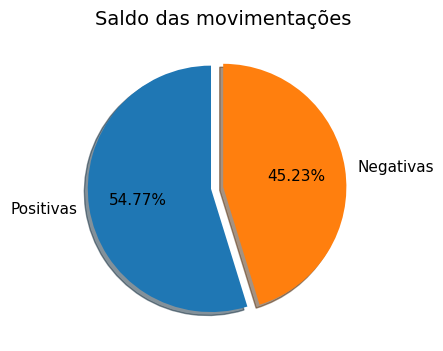

In [8]:
# plotando o gráfico para exibir a porcentagem do saldo das movimentações
plt.figure(figsize=(8,4))

plt.pie (
    [positivas, negativas],
    labels = ['Positivas', 'Negativas'],
    autopct = '%.2f%%',
    explode = [0.1, 0],
    textprops = {'fontsize': 11},
    shadow = True,
    startangle = 90
)

plt.title('Saldo das movimentações', fontdict = {'size': 14})
plt.show()

# Gráfico 2 - Top 10 Cargos por CBO

In [9]:
# contando os registros para encontrar os 10 maiores cbo pelo código
caged_filtrado['cd_cbo'].value_counts().head(10)

223505    15417
212405    11190
223405    10754
212420     9477
224120     5237
223710     3435
223605     3314
225125     2772
212410     2371
214205     1975
Name: cd_cbo, dtype: int64

### Identificando os cargos pelos códigos encontrados

223505 - Enfermeiro  
212405 - Analista de Desenvolvimento de Sistemas  
223405 - Farmacêutico  
212420 - Analista de Suporte Computacional  
224120 - Preparador Físico  
223710 - Nutricionista  
223605 - Fisioterapeuta Geral  
225125 - Médico Clínico  
212410 - Analista de Redes e de Comunicação de Dados  
214205 - Engenheiro Civil

In [10]:
# puxando a planilha que contém a descrição dos cbo existentes
cargos = pd.read_excel('Descrição das variáveis.xlsx', sheet_name='cd_cbo', engine='openpyxl')
display(cargos)

,Código,Descrição
0,10105,Oficial General da Aeronautica
1,10110,Oficial General do Exercito
2,10115,Oficial General da Marinha
3,10205,Oficial da Aeronautica
4,10210,Oficial do Exercito
...,...,...
2773,992210,Encarregado de Equipe de Conservacao de Vias P...
2774,992215,Operador de Ceifadeira na Conservacao de Vias ...
2775,992220,Pedreiro de Conservacao de Vias Permanentes (E...
2776,992225,Auxiliar Geral de Conservacao de Vias Permanen...


In [11]:
# unindo as planilhas e relacionando as colunas com o cbo para puxar a descrição
caged_cargos = caged_filtrado.merge(cargos, how='inner', left_on='cd_cbo', right_on='Código')
display(caged_cargos)

,cd_uf,cd_mun,dt_competencia,cd_admitidos_desligados,cd_cbo,nr_horas,nr_salario,nr_saldo,cd_tipo_movimentacao,cd_cnae_classe,fonte,nr_admitidos,nr_desligados,cd_cnae_sub,cd_familia,Código,Descrição
0,42,420460,202101,NaN,224135,4400.0,"3000,00",1,43,85911,CAGEDEXC202104,0,-1,8591100,2241,224135,Treinador Profissional de Futebol
1,42,420460,202101,NaN,224135,4400.0,"1045,00",1,43,85911,CAGEDEXC202104,0,-1,8591100,2241,224135,Treinador Profissional de Futebol
2,42,420540,202101,NaN,224135,4400.0,"37058,82",-1,43,93123,CAGEDFOR202102,0,1,9312300,2241,224135,Treinador Profissional de Futebol
3,42,420540,202101,NaN,224135,4400.0,"2782,17",-1,31,93123,CAGEDFOR202102,0,1,9312300,2241,224135,Treinador Profissional de Futebol
4,42,420540,202101,NaN,224135,4400.0,"2077,80",-1,31,93123,CAGEDFOR202102,0,1,9312300,2241,224135,Treinador Profissional de Futebol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87670,42,421175,202210,NaN,214520,4400.0,"17600,00",1,97,33147,CAGEDMOV202210,1,0,3314799,2145,214520,Engenheiro Quimico (Papel e Celulose)
87671,42,420240,202210,NaN,225315,4400.0,"39600,00",1,97,86402,CAGEDMOV202210,1,0,8640205,2253,225315,Médico em Medicina Nuclear
87672,42,420540,202211,NaN,213115,3000.0,"4755,75",1,97,26213,CAGEDMOV202211,1,0,2621300,2131,213115,Fisico (Atomica e Molecular)
87673,42,420540,202212,NaN,213115,3000.0,"4755,75",-1,43,26213,CAGEDMOV202212,0,1,2621300,2131,213115,Fisico (Atomica e Molecular)


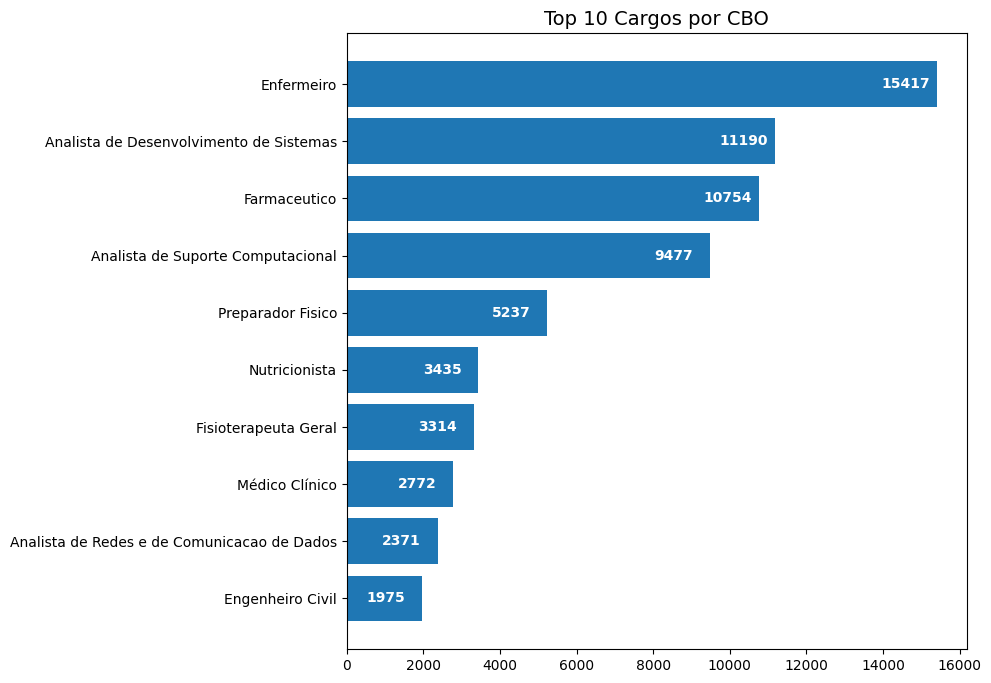

In [12]:
# plotando o gráfico para exibir os 10 cargos com maior quantidade de cbo
plt.figure(figsize=(8,8))

# define os eixos do gráfico, conta os valores e ordena de forma decrescente
# transforma os valores dos eixos em lista e cria um dicionário para a descrição
descricao = list(caged_cargos['Descrição'].value_counts(ascending=False).keys())
qtd_cbo = list(caged_filtrado['cd_cbo'].value_counts(ascending=False))

# define o top 10 de cada eixo em uma nova variável e aplica ela de volta nos eixos
local = pd.DataFrame({'Cargos': descricao, 'Quantidade por CBO': qtd_cbo}).head(10)
descricao = local['Cargos']
qtd_cbo = local['Quantidade por CBO']

# adiciona e formata os rótulos de dados nas barras horizontais
splot=sns.barplot(x=qtd_cbo, y=descricao, data=local)
plt.bar_label(splot.containers[0], padding=-40, color='white', weight='bold')

plt.barh(descricao, qtd_cbo)

# oculta os rótulos dos eixos
plt.xlabel('') 
plt.ylabel('')

plt.title('Top 10 Cargos por CBO', fontdict = {'size': 14})
plt.show()

# Gráfico 3 - Comparação de admitidos x desligados

In [13]:
# conta os valores da coluna de admitidos
caged_filtrado['nr_admitidos'].value_counts()

 1    47991
 0    39633
-1       51
Name: nr_admitidos, dtype: int64

In [14]:
# cria variáveis para os valores encontrados
admitidos, nao_admitidos, nao_identificados = caged_filtrado['nr_admitidos'].value_counts()

In [15]:
# cria uma variável que recebe a quantidade real de admitidos pelo total de dados da coluna
admissoes = admitidos / caged_filtrado.shape[0] * 100

In [16]:
# conta os valores da coluna de desligados
caged_filtrado['nr_desligados'].value_counts()

 0    48042
 1    39603
-1       30
Name: nr_desligados, dtype: int64

In [17]:
# cria variáiveis para os valores encontrados
nao_desligados, desligados, nao_identificados = caged_filtrado['nr_desligados'].value_counts()

In [18]:
# cria uma variável que recebe a quantidade real de desligados pelo total de dados da coluna
demissoes = desligados / caged_filtrado.shape[0] * 100

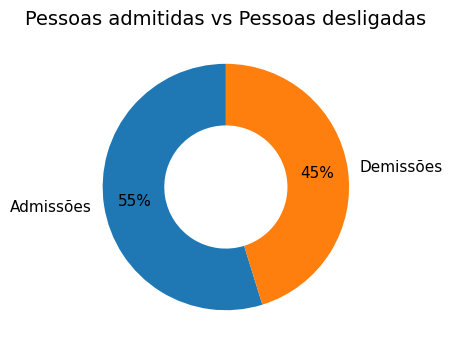

In [19]:
# plotando o gráfico com a diferença entre admitidos e desligados
plt.figure(figsize=(8,4))

plt.pie(
    [admissoes, demissoes],
    labels=['Admissões', 'Demissões'],
    autopct='%.f%%',
    pctdistance=0.75,
    textprops = {'fontsize': 11},
    startangle=90,
    wedgeprops=dict(width=0.5)
)

plt.title('Pessoas admitidas vs Pessoas desligadas', fontdict = {'size': 14})
plt.show()

# Gráfico 4 - Top 5 tipos de movimentação

In [20]:
# contando os registros para encontrar os 5 maiores tipos de movimentações pelo código
caged_filtrado['cd_tipo_movimentacao'].value_counts().head(5)

97    36479
40    22035
31    12921
20     9970
43     3155
Name: cd_tipo_movimentacao, dtype: int64

### Identificando os tipos de movimentações pelos códigos encontrados

97 - Admissão de tipo ignorado  
40 - Desligamento a pedido  
31 - Desligamento por demissão sem justa causa  
20 - Admissão por reemprego  
43 - Término contrato trabalho prazo determinado

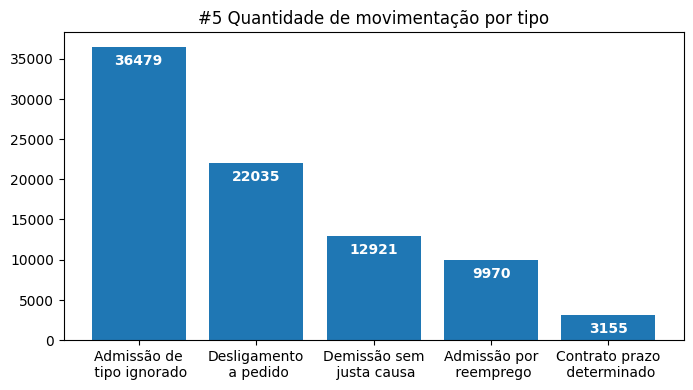

In [21]:
# plotando o gráfico para exibir os 5 principais tipos de movimentação
plt.figure(figsize=(8,4))

# formatando os tipos de acordo com a tabela de descrição das variáveis
# optei por formatar manualmente, por estar utilizando as barras na vertical
tipo_movimentacao = [
    'Admissão de\n tipo ignorado',
    'Desligamento\n a pedido',
    'Demissão sem\n justa causa',
    'Admissão por\n reemprego',
    'Contrato prazo\n determinado'
]
qtd_movimentacao = caged_filtrado['cd_tipo_movimentacao'].value_counts().head(5)

# adiciona e formata os rótulos de dados nas barras verticais
splot=sns.barplot(x=tipo_movimentacao, y=qtd_movimentacao)
plt.bar_label(splot.containers[0], padding=-15, color='white', weight='bold')

plt.bar(tipo_movimentacao, qtd_movimentacao)
plt.title('#5 Quantidade de movimentação por tipo')

# oculta os rótulos dos eixos
plt.xlabel('') 
plt.ylabel('')

plt.show()